In [63]:
pip install colorlog

Note: you may need to restart the kernel to use updated packages.


In [64]:
from typing import Optional
from dotenv import load_dotenv
load_dotenv()
import os
import logging as logger
from azure.core.credentials import AzureKeyCredential
from openai import AzureOpenAI, OpenAI
from app.utils.azure_ai_search_retriever import AzureAISearchRetriever, SearchCredential
from app.utils.rag_orchestrator import RAGOrchestrator
from typing import List
import base64
import openai

logger.getLogger().setLevel(logger.WARN)


In [65]:

def create_search_credential() -> SearchCredential:
    """Creates the appropriate Azure Search credential based on environment variables."""
    api_key = os.getenv("AZURE_SEARCH_API_KEY")
    if api_key:
        logger.info("Using Azure Search API Key credential.")
        return AzureKeyCredential(api_key)


def create_openai_client(purpose: str = "embedding") -> Optional[AzureOpenAI | OpenAI]:
    """Creates an AzureOpenAI client instance based on environment variables."""
    if purpose == "embedding":
        endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
        api_key = os.getenv("AZURE_OPENAI_API_KEY")
        api_version = os.getenv("AZURE_OPENAI_API_VERSION")
        log_prefix = "Embedding"
    elif purpose == "chat":
        endpoint = None
        api_version = None
        api_key = os.getenv("AZURE_OPENAI_CHAT_API_KEY", os.getenv("AZURE_OPENAI_API_KEY"))
        log_prefix = "Chat"
    else:
        raise ValueError(f"Invalid purpose for OpenAI client: {purpose}")

    try:
        if endpoint is None or api_version is None:
            client = OpenAI(
                api_key=api_key,
            )
        else:
            client = AzureOpenAI(
                azure_endpoint=endpoint,
                api_key=api_key,
                api_version=api_version,
            )
        # Perform a simple test if needed (e.g., list models), but might add latency
        logger.info(
            f"Azure OpenAI client for {log_prefix} initialized successfully (Endpoint: {endpoint}, API Version: {api_version}).")
        return client
    except Exception as e:
        logger.error(f"Failed to initialize Azure OpenAI {log_prefix} client: {e}", exc_info=True)
        return None  # Return None instead of raising, allow graceful failure if only one part is needed

def encode_file(file_path):
    with open(file_path, "rb") as file:
        return base64.b64encode(file.read()).decode('utf-8')


In [67]:
# --- Azure Search Configuration ---
search_service_name = os.getenv("AZURE_SEARCH_SERVICE_NAME")
index_name = os.getenv("AZURE_SEARCH_INDEX_NAME")
search_dns_suffix = os.getenv("AZURE_SEARCH_DNS_SUFFIX", "search.windows.net")

if not search_service_name or not index_name:
    raise ValueError("Missing required environment variables: AZURE_SEARCH_SERVICE_NAME and AZURE_SEARCH_INDEX_NAME")

search_service_endpoint = f"https://{search_service_name}.{search_dns_suffix}"
search_credential = create_search_credential()  # Handles API key, SPN, DefaultAzureCredential

# --- Azure OpenAI Configuration ---
# Embedding Client (Optional for Retriever if only doing text search)
openai_embedding_client = create_openai_client(purpose="embedding")
openai_embedding_deployment = os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT")

# Chat Client (Required for Orchestrator)
openai_chat_client = create_openai_client(purpose="chat")
openai_chat_deployment = os.getenv("AZURE_OPENAI_CHAT_DEPLOYMENT")

if not openai_chat_client or not openai_chat_deployment:
    raise ValueError(
        "Azure OpenAI Chat client configuration (Endpoint, Key, Version, Deployment) is required and incomplete.")

In [ ]:
# --- Instantiate Retriever ---
retriever = AzureAISearchRetriever(
    search_service_endpoint=search_service_endpoint,
    index_name=index_name,
    search_credential=search_credential,
    openai_client=openai_embedding_client,  # Pass the client instance
    openai_embedding_deployment=openai_embedding_deployment  # Pass the deployment name
    # select_fields=None, # Use default
    # embedding_dimension=1536 # Use default
)
logger.info("AzureAISearchRetriever instantiated.")

# --- Instantiate Orchestrator ---
orchestrator = RAGOrchestrator(
    retriever=retriever,
    chat_client=openai_chat_client,  # Pass the client instance
    chat_deployment=openai_chat_deployment  # Pass the deployment name
    # system_prompt="Your custom system prompt here", # Optional
    # context_template="Source: {source}\nContent: {content}\n---\n", # Optional
)
logger.info("RAGOrchestrator instantiated.")

In [ ]:
# --- Example Query ---
user_query = "Why do we need to do Business Process Re-engineering as a part of implementing an HIS/EHR? Note: Your answer must be in your own words."
logger.info(f"Answering query: '{user_query}'")

answer, sources = orchestrator.answer_query(
    user_query=user_query,
    top_k_retrieval=3,
    search_type="hybrid",  # Try hybrid search
    use_semantic_ranking=False  # Set to True if configured and desired
)

if answer:
    print("\n--- Answer ---")
    print(answer)
    print("\n--- Sources ---")
    if sources:
        for source in sources:
            print(f"- {source}")
    else:
        print("No sources were cited (or retrieval failed).")
else:
    print("\nFailed to get an answer.")


--- Answer ---
Business Process Re-engineering (BPR) is essential when implementing a Health Information System (HIS) or Electronic Health Record (EHR) because the adoption of such systems fundamentally changes workflows, clinical processes, and operational structures. The process ensures that the organization’s workflows are aligned with the new technology, maximizing its benefits and ensuring a smooth transition. For example, during an EHR implementation, customized clinical content, workflows, and tools need to be developed and refined to meet the organization’s specific needs (Source: Assignment2_relevant_material.pdf). Additionally, re-engineering workflows allows for improvements in quality and consistency of documentation, coding, and other processes that might have been inefficient or inconsistent with manual or previous systems (Source: Assignment2_relevant_material.pdf).

Moreover, BPR enables the identification and resolution of problematic workflows before implementation, 

## Load Google Drive Files
Since our datasets live in Google Drive, we connect to our data source. This particular method assumes you have [Drive for Desktop](https://dl.google.com/drive-file-stream/GoogleDriveSetup.exe) installed on your computer and you are accessing a local path. For this POC, we focus on assignment 2.

In [ ]:
class StudentResponse:
    rubric_path: str
    submission_path: str
    def __init__(self, rubric_path, submission_path):
        self.rubric_path = rubric_path
        self.submission_path = submission_path

In [ ]:
# Initialize list to hold student responses
student_responses: List[StudentResponse] = []
# Relevant material list
relevant_material = r"G:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Quiz_1\Module 1 Lecture Materials.pdf""
assignment_requirements = r"I:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Assignment 2 – EHR Functional Requirements Worksheet\CS581 Assignment 2 HIS Clinical (EHR) Functional Requirements 2025 Spring 1.pdf"

In [ ]:
# Define the base directory
base_dir = r"G:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Quiz_1"

# Iterate through student directories
for student_number in os.listdir(base_dir):
    student_path = os.path.join(base_dir, student_number)

    if os.path.isdir(student_path):  # Ensure it's a directory
        rubric_path = os.path.join(student_path, "rubric.docx")
        submission_path = os.path.join(student_path, "submission.pptx")

        # Check if both expected files exist
        if os.path.exists(rubric_path) and os.path.exists(submission_path):
            student_responses.append(StudentResponse(rubric_path=rubric_path, submission_path=submission_path))

In [ ]:
response = openai_chat_client.responses.create(
    model="gpt-4o",
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": "Please analyze the attached file."
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "input_file",
                    "filename": os.path.basename(relevant_material),
                    "file_data": f"data:application/pdf;base64,{encode_file(relevant_material)}"
                }
            ]
        }
    ],
    text={
        "format": {
            "type": "text"
        }
    },
    reasoning={},
    tools=[],
    temperature=1,
    max_output_tokens=2048,
    top_p=1,
    store=True
)


In [ ]:
pip install weave

  Using cached wandb-0.19.8-py3-none-win_amd64.whl.metadata (10 kB)
  Using cached docker_pycreds-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached GitPython-3.1.44-py3-none-any.whl.metadata (13 kB)
  Using cached setproctitle-1.3.5-cp312-cp312-win_amd64.whl.metadata (10 kB)
  Using cached backoff-2.2.1-py3-none-any.whl.metadata (14 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   --------------------------------------- 590.6/590.6 kB 21.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.6 MB 13.4 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.6 MB 15.2 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.6 MB 13.6 MB/s eta 0:

In [ ]:
from getpass import getpass

In [ ]:
oai_api_key = getpass("Enter your OpenAI API Key: ")

## Experiment 1: Rewriting A Response

In [ ]:
# This experiment will grade the same student responses over and over again and will see how changing the temperature hyperparameter changes the response
# Weave will track the inputs, outputs and code of this function
import weave
import json
from openai import OpenAI

@weave.op() # 🐝 Decorator to track requests
def rewrite_response(sentence: str, temp: float) -> str:
    client = OpenAI(api_key=oai_api_key)
    system_prompt = "You will receive a written response from a student. What you need to do is take the student's" \
    "response, and simply rewrite it in a different way. You must retain all of the content of the response, but the goal" \
    "is to restructure and reword the response, so that it receives the same exact grade from a human grader as the student's" \
    "submission originally did. Your variations can include things like stronger or weaker language, synonyms, etc, but it still" \
    "must be the same overall content."
    response = client.chat.completions.create(
      model="gpt-4o",
      messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": sentence}
      ],
      temperature=temp,
      response_format={"type": "text"}
    )
    extracted = response.choices[0].message.content
    return extracted
rewritten_responses = []
weave.init('ML Autograder-Rewriting') #

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/weave


In [ ]:
import tqdm as tqdm

In [ ]:
sentence = "Short Answer Question: What is one benefit of using an Enterprise Architecture and why is it a benefit?" \
"Student Respone: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. " \
"This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is " \
"easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical " \
"issues (such as security), and portability of applications. "

print(sentence)

for i in tqdm.tqdm(range(100)):
    response = rewrite_response(sentence, .75)

    rewritten_responses.append(response)

Short Answer Question: What is one benefit of using an Enterprise Architecture and why is it a benefit?Student Respone: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical issues (such as security), and portability of applications. 


  0%|          | 0/100 [00:00<?, ?it/s]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8b-0556-7803-a1b1-0e4b3dab6cef


  1%|          | 1/100 [00:02<03:58,  2.41s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8b-0ebb-7081-86c1-141702ce677a


...

 98%|█████████▊| 98/100 [03:44<00:03,  1.99s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8e-7361-7bf0-b58f-aab6e04cb2a6


 99%|█████████▉| 99/100 [03:46<00:02,  2.04s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8e-7bd7-7c02-9770-1c6059b4e33b


100%|██████████| 100/100 [03:48<00:00,  2.29s/it]


In [ ]:
print(f"Original: {sentence.split('Respone: ')[1]}\n")
for i, response in enumerate(rewritten_responses):
    print(f"Response {i}: {response}\n")

Original: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical issues (such as security), and portability of applications. 

Response 0: One advantage of employing Enterprise Architecture is the enhancement of IT operations, leading to greater efficiency. This is advantageous because it results in reduced costs for software development, support, and maintenance, simplifies system and network management, and facilitates the upgrading and swapping of system components. Additionally, Enterprise Architecture boosts interoperability, enhances the capacity to tackle critical issues like security, and improves the portability of applications.

Response 1: One advantage of implementing 

## Grading Experiments

In [68]:
import math

def compute_ratio(ratio_str):
    try:
        # Split the string and convert to floats
        numerator, denominator = map(float, ratio_str.split('/'))
        return numerator / denominator
    except Exception:
        # Return NaN if there's any error (e.g., wrong format or conversion error)
        return math.nan

In [71]:
import pandas as pd

In [72]:
import weave
from openai import OpenAI

question = "Short Answer Question (14 Points): What is one benefit of using an Enterprise Architecture and why is it a benefit?"

unclear_rubric = '''Grading Rubric: 14 TOTAL POINTS
Other reasonable answers are also allowed.

- Present and support the current and future vision of a business and the related As-Is to Should-Be process re-engineering.
- Support quality decision-making such as investment choices and to manage the impact of changes on the organization.
- Optimize IT to support business operations in a cost-effective manner by helping to:
a. Reduce redundancy
b. Reuse existing information and software components
c. Leverage new technology solutions in an EHR system effectively
d. Align closely with an organization's mission and goals and the goals of key stakeholders, both internal and external to the enterprise.

- Combine the technology, systems, business and market options to fulfill the enterprise mission, taking into consideration the:
a. External environment—Like the ARRA and HighTech Act
b. Mission of the healthcare organization—A large, metropolitan teaching hospital has different needs from a small private practice in the suburbs.
c. Business strategy (such as emphasis on particular populations or diseases )
d. Business models (e.g., transformation to shared financial risk business models like accountable care organizations)
e. Technology (including existing and new technologies like an EHR
 
- Help enable a more efficient IT Operation:
a. Lower software development, support, and maintenance costs
b. Increased portability of applications
c. Improved interoperability and easier system and network management
d. Improved ability to address critical enterprise-wide issues like security
e. Easier upgrade and exchange of system components

- Better return on existing investment and reduced need for future investment:
a. Reduced complexity in the IT infrastructure
b. Maximum return on investment in the existing IT infrastructure
c. The flexibility to make, buy, or out-source IT solutions
d. Reduced overall new investment lower total cost of IT ownership

- Faster, simpler, and cheaper procurement:
a. Buying decisions are simpler, because the information governing procurement is readily available in a coherent plan.
b. The procurement process is faster—maximizing procurement speed and flexibility without sacrificing architectural coherence.
c. The ability to procure heterogeneous, multi-vendor, open systems.'''

clear_rubric = '''Structured Rubric:
 # Structured Grading Rubric for Short Answer Question

## Task
- **Question**: What is one benefit of using an Enterprise Architecture and why is it a benefit?
- **Note**: Students should only provide one benefit. The emphasis is on the depth and detail of the explanation for that single benefit.

## Scoring Criteria

### 1. Explanation of the Benefit (0-6 Points)
- **Detailed Explanation**: The student provides a comprehensive and detailed explanation of the chosen benefit. (5-6 Points)
- **Moderate Explanation**: The explanation of the benefit is clear but lacks depth or detail. (3-4 Points)
- **Basic Explanation**: The explanation is vague or lacks clarity. (1-2 Points)
- **No Explanation**: The benefit is mentioned without any explanation. (0 Points)

### 2. Relevance and Accuracy (0-4 Points)
- **Highly Relevant and Accurate**: The benefit is clearly relevant to Enterprise Architecture, and the explanation is accurate and precise. (3-4 Points)
- **Partially Relevant or Accurate**: Some aspects of the benefit are relevant, but there are minor inaccuracies. (1-2 Points)
- **Irrelevant or Inaccurate**: The benefit is not relevant to Enterprise Architecture or contains major inaccuracies. (0 Points)

### 3. Additional Insights and Justification (0-4 Points)
- **Comprehensive Insights**: The student provides additional insights or justifications, such as examples or implications, that enhance the understanding of the benefit. (3-4 Points)
- **Some Insights**: Some additional insights or justifications are provided, but they are limited. (1-2 Points)
- **No Additional Insights**: The explanation lacks additional insights or justifications. (0 Points) '''

@weave.op() # 🐝 Decorator to track requests
def grade_response(question: str, student_response: str, rubric: str, temp=.5) -> str:
    client = OpenAI(api_key=oai_api_key)
    system_prompt = f"You are provided with a short response question, and a grading rubric that lists some of the acceptable repsonses. Based on the rubric and the response," \
    f"You will grade the response out of the allotted points for the question, which is 14 points, as noted in the question itself. You " \
    f"should make the grade that you provide very clear so that it can easily be located in your response. When grading the response, only take into account the content of the rubric," \
    f"and not anything else such as strength of language or spelling errors. Read the question's instructions and rubric very carefully. Here is the question: {question} \n Here is the rubric:" \
    f" {rubric} \n In addition to the grade that you provide, provide your reasoning behind the grade."
    response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": student_response}
    ],
    temperature=temp,
    response_format={"type": "text"}
    )
    extracted = response.choices[0].message.content
    return extracted

@weave.op
def extract_llm_score(summary: str, temp=.1) -> dict:
    client = OpenAI(api_key=oai_api_key)
    res = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are provided with a graded response of a student submission." \
"The graded response may include various points of feedback and words, but it will also include a number grade" \
"out of 14 points. I want you to find this score that is provided in response and respond with that score only, nothing else." \
"For example, if the grade provided is 7/14, or 7 out of 14, then I want you to return the ratio of the grade, so it would be 7/14." \
"Note that I am running automated computation with the output, so the format of the response must be NUMERATOR/DENOMINATOR and that is it!"},
            {"role": "user", "content": (
                f"Extract the grade and return in N/D format: "
                f"Summary: {summary}"
            )}], 
            temperature=temp,
            response_format={"type": "text"})
    extracted = res.choices[0].message.content
    return extracted


### Experiment 2: Grading One Response 100 Times (default temperature)

In [ ]:
weave.init('ML Autograder-Grading(original)')

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/weave


In [75]:
# Grading the one response 100 times with the good rubric to measure consistency

num_trials = 100
experiment2_dataset = {"Trial Number": [],
                      "Unprocessed Scoring": [],
                      "Located Score": [],
                      "Processed Score": []}

submission = sentence # from previous section

for i in tqdm.tqdm(range(num_trials)):
    experiment2_dataset["Trial Number"].append(i)

    graded_response, call = grade_response.call(question, submission, clear_rubric)
    experiment2_dataset["Unprocessed Scoring"].append(graded_response)

    score = extract_llm_score(graded_response)
    experiment2_dataset["Located Score"].append(score)

    processed_score = compute_ratio(score)
    experiment2_dataset["Processed Score"].append(processed_score)

100%|██████████| 100/100 [11:07<00:00,  6.67s/it]


In [77]:
df = pd.DataFrame(experiment2_dataset)
df

,Trial Number,Unprocessed Scoring,Located Score,Processed Score
0,0,**Grade: 11/14**\n\n**Explanation of the Benef...,11/14,0.785714
1,1,**Grade: 9/14**\n\n**Explanation of the Benefi...,9/14,0.642857
2,2,**Grade: 9/14**\n\n**Explanation of the Benefi...,9/14,0.642857
3,3,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
4,4,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
...,...,...,...,...
95,95,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
96,96,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
97,97,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
98,98,### Grading:\n\n1. **Explanation of the Benefi...,11/14,0.785714


In [79]:
processed_scores = df['Processed Score']
unique_counts = processed_scores.value_counts().sort_index()
print("Unique values and their counts:")
print(unique_counts)


Unique values and their counts:
Processed Score
0.571429     1
0.642857    22
0.714286    67
0.785714    10
Name: count, dtype: int64


In [80]:
mean_val = processed_scores.mean()
variance_val = processed_scores.var()  # sample variance
std_dev_val = processed_scores.std()    # sample standard deviation

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_dev_val)


Mean: 0.7042857142857143
Variance: 0.001754277468563181
Standard Deviation: 0.04188409565172896


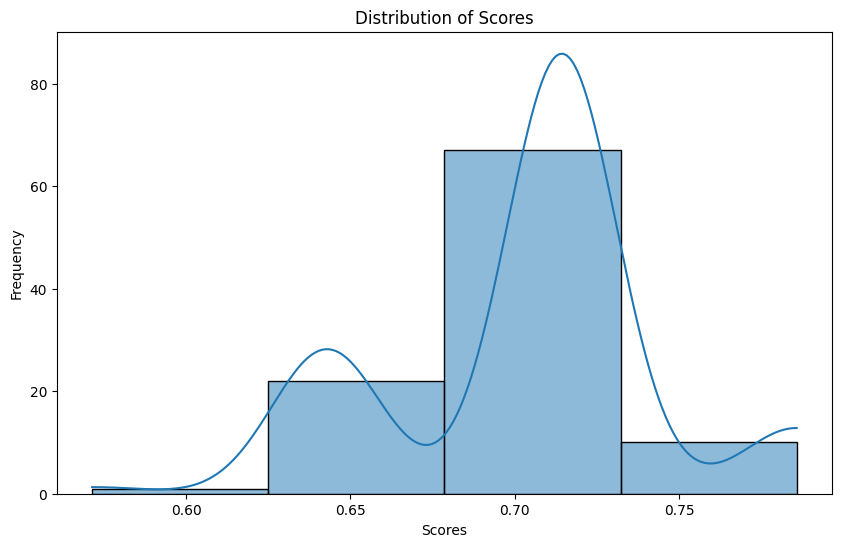

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(processed_scores, bins=4, kde=True)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

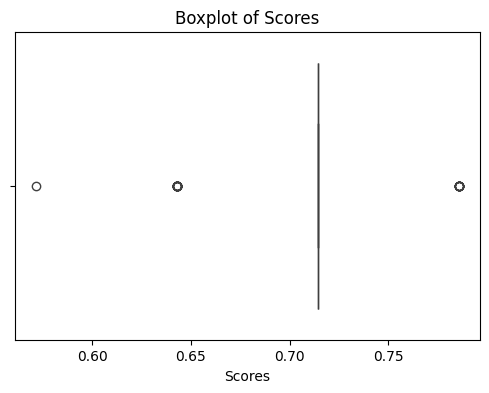

In [86]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=processed_scores)
plt.title("Boxplot of Scores")
plt.xlabel("Scores")
plt.show()

C:\Users\TasSp\AppData\Local\Temp\ipykernel_187684\1452912131.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(processed_scores, shade=True)


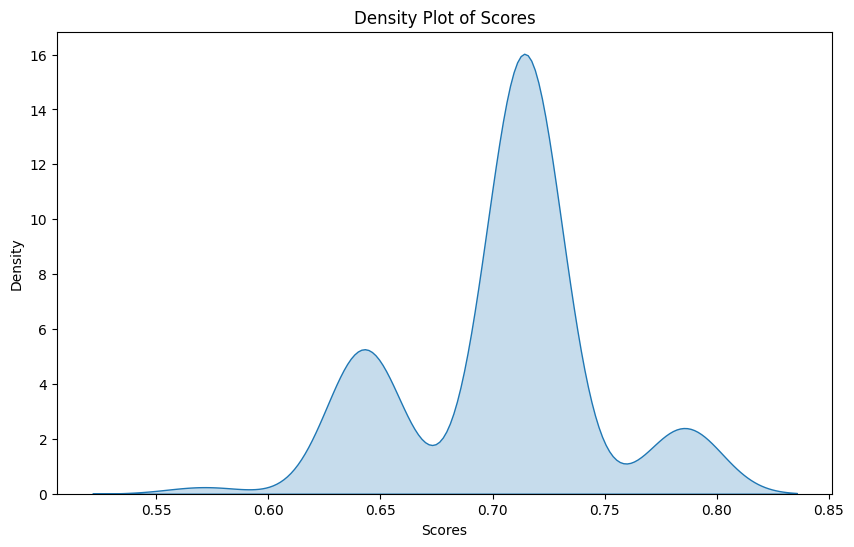

In [88]:
plt.figure(figsize=(10, 6))
sns.kdeplot(processed_scores, shade=True)
plt.title("Density Plot of Scores")
plt.xlabel("Scores")
plt.ylabel("Density")
plt.show()

### Experiment 3: Grading 100 Rewritten Versions of the Same Response (default temperature)

In [89]:
weave.init('ML Autograder-Grading(rewritten)') #

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/weave


In [90]:
# Grading the 100 rewritten variations of the original response to measure consistency

num_trials = 100
experiment3_dataset = {"Submission Number": [],
                      "Submission": [],
                      "Unprocessed Scoring": [],
                      "Located Score": [],
                      "Processed Score": []}

for i in tqdm.tqdm(range(num_trials)):
    experiment3_dataset["Submission Number"].append(i)

    submission = rewritten_responses[i]
    experiment3_dataset["Submission"].append(submission)

    graded_response, call = grade_response.call(question, submission, clear_rubric)
    experiment3_dataset["Unprocessed Scoring"].append(graded_response)

    score = extract_llm_score(graded_response)
    experiment3_dataset["Located Score"].append(score)

    processed_score = compute_ratio(score)
    experiment3_dataset["Processed Score"].append(processed_score)

  0%|          | 0/100 [00:00<?, ?it/s]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-15cd-7023-8dc0-24ed4844fd7b
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-2c1c-75a2-abe0-6353938c864a


  1%|          | 1/100 [00:06<10:56,  6.63s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-2fad-7443-b188-e41b46eda5d2
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-3e47-77c2-a5fd-c9d74f55805f


  2%|▏         | 2/100 [00:11<08:46,  5.37s/it]

...

 98%|█████████▊| 98/100 [09:38<00:12,  6.12s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f035-eb2a-7520-916f-0a86a7ca27ba
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f036-0031-7e82-9bc2-cf709d476e8c


 99%|█████████▉| 99/100 [09:45<00:06,  6.19s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f036-03eb-7c51-b92c-eb8c80f38a92
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f036-11e1-7d13-8008-b8c03d626bcb


100%|██████████| 100/100 [09:49<00:00,  5.90s/it]


In [91]:
df2 = pd.DataFrame(experiment3_dataset)
df2

,Submission Number,Submission,Unprocessed Scoring,Located Score,Processed Score
0,0,One advantage of employing Enterprise Architec...,**Grade: 12/14 Points**\n\n**Explanation of th...,12/14,0.857143
1,1,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
2,2,A key advantage of utilizing an Enterprise Arc...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
3,3,One advantage of utilizing an Enterprise Archi...,Grade: 12/14\n\nReasoning:\n\n1. **Explanation...,12/14,0.857143
4,4,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Reasoning:**\n\n1. **Exp...,12/14,0.857143
...,...,...,...,...,...
95,95,One advantage of utilizing an Enterprise Archi...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
96,96,A key advantage of employing an Enterprise Arc...,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
97,97,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
98,98,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143


In [92]:
processed_scores = df2['Processed Score']
unique_counts = processed_scores.value_counts().sort_index()
print("Unique values and their counts:")
print(unique_counts)

Unique values and their counts:
Processed Score
0.714286     1
0.785714     1
0.857143    90
0.928571     5
1.000000     3
Name: count, dtype: int64


In [93]:
mean_val = processed_scores.mean()
variance_val = processed_scores.var()  # sample variance
std_dev_val = processed_scores.std()    # sample standard deviation

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_dev_val)

Mean: 0.8628571428571429
Variance: 0.0011008039579468159
Standard Deviation: 0.033178365811878316


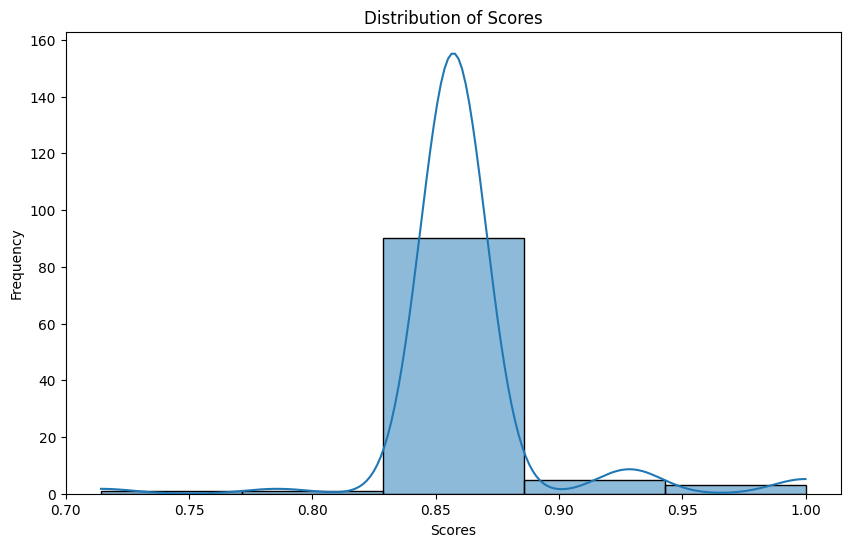

In [95]:
plt.figure(figsize=(10, 6))
sns.histplot(processed_scores, bins=5, kde=True)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

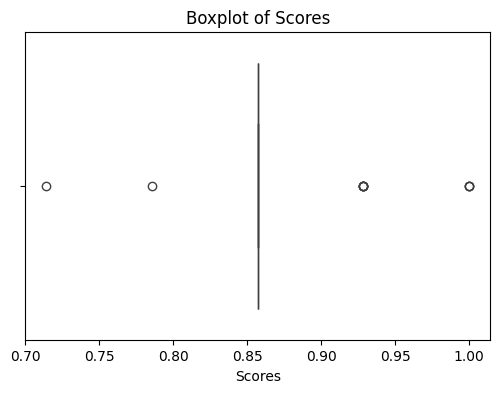

In [94]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=processed_scores)
plt.title("Boxplot of Scores")
plt.xlabel("Scores")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(processed_scores, shade=True)
plt.title("Density Plot of Scores")
plt.xlabel("Scores")
plt.ylabel("Density")
plt.show()

In [ ]:
from IPython.display import Markdown, display
display(Markdown(response.output[0].content[0].text))

### Virginia Women’s Center Case Study Overview

#### Organizational Overview
- **Location:** Richmond, Virginia
- **Services:** Comprehensive women’s health, including Ob/Gyn, female urology, pelvic surgery, psychology, nutrition, and genetics.
- **Staff:** 25 physicians and 12 mid-level providers at five clinical locations.
- **Specialized Services:** Digital mammography, bone densitometry, and ultrasonography.
- **Hospitals:** Affiliated with five local hospitals.
- **Payors:** Anthem, Aetna, United Healthcare, and others. Also participates in programs for uninsured and underinsured.

#### EHR Implementation Goals
- **Challenges:** Slow chart turnaround, high costs, and legibility issues.
- **Objectives:** Reduce costs, improve revenue cycle, enhance patient and staff satisfaction, and enable remote access for providers.

#### Implementation Strategy
- **Approach:** Phased implementation across locations over 14 months.
- **Staff Involvement:** 100% physician buy-in required, with a sequential approach for training.
- **Pilot Site:** Initial implementation at the smallest office.

#### Training and Support
- **EHR Team:** Comprised of clinical directors and physician champions who provided ongoing support and training.
- **Vendor Support:** Initial on-site training was provided with subsequent remote support.

#### Tools and Standards
- **Documentation:** Standardized forms and procedures across all locations.
- **Interfaces:** Established with labs and imaging systems for seamless integration.

#### Results and Benefits
- **Financial:** Initial $300,000 transcription cost savings; unexpected staffing ratio increase but productivity gains.
- **Operational:** 11% increase in patient visits, 13% increase in relative value units (RVUs).
- **Efficiency:** Reduction in charge entry staff needed due to electronic processing.
- **Quality of Care:** Improved tracking and patient safety measures due to electronic workflows.

#### Lessons Learned
- **Challenges:** Issues with patient-entered data and initial workflow designs.
- **Critical Success Factors:** Phased rollout, thorough vendor evaluation, and engaged staff.

#### Future Directions
- **Integration:** Aim for further integration with external health information systems for enhanced patient data access.
- **Patient Engagement:** Enhance patient interaction through secure messaging and online access to records.

### Key Takeaways
The Virginia Women’s Center’s transition to an EHR system illustrates a successful blend of technology adoption with focused training and staff engagement, resulting in improved workflows, financial performance, and patient care.